# Importing libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

# loading data

In [2]:
steel_data=pd.read_csv("new_new_steel_data")
steel_data

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,DayOfWeek,Month,Is_weekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load,0,0,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load,1,0,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load,1,0,1,0,1.545117,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,2018-12-31 23:00:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load,23,0,12,0,1.610306,0
35036,2018-12-31 23:15:00,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load,23,0,12,0,1.414227,0
35037,2018-12-31 23:30:00,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load,23,0,12,0,1.304881,0
35038,2018-12-31 23:45:00,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load,23,0,12,0,1.286155,0


In [3]:
steel_data.isna().sum()

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
Hour                                    0
DayOfWeek                               0
Month                                   0
Is_weekend                              0
Power_Factor_Ratio                      1
High_Load                               0
dtype: int64

# Dropping features that can leake data

In [4]:
steel_data=steel_data.drop(["High_Load","Power_Factor_Ratio","date"], axis=1)
steel_data

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,DayOfWeek,Month,Is_weekend
0,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load,0,0,1,0
1,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load,0,0,1,0
2,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load,0,0,1,0
3,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load,1,0,1,0
4,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load,23,0,12,0
35036,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load,23,0,12,0
35037,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load,23,0,12,0
35038,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load,23,0,12,0


# Independent x

In [5]:
x = steel_data.drop("Lagging_Current_Power_Factor", axis=1)
x

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,DayOfWeek,Month,Is_weekend
0,3.17,2.95,0.00,0.0,100.00,900,Weekday,Monday,Light_Load,0,0,1,0
1,4.00,4.46,0.00,0.0,100.00,1800,Weekday,Monday,Light_Load,0,0,1,0
2,3.24,3.28,0.00,0.0,100.00,2700,Weekday,Monday,Light_Load,0,0,1,0
3,3.31,3.56,0.00,0.0,100.00,3600,Weekday,Monday,Light_Load,1,0,1,0
4,3.82,4.50,0.00,0.0,100.00,4500,Weekday,Monday,Light_Load,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,3.85,4.86,0.00,0.0,100.00,82800,Weekday,Monday,Light_Load,23,0,12,0
35036,3.74,3.74,0.00,0.0,100.00,83700,Weekday,Monday,Light_Load,23,0,12,0
35037,3.78,3.17,0.07,0.0,99.98,84600,Weekday,Monday,Light_Load,23,0,12,0
35038,3.78,3.06,0.11,0.0,99.96,85500,Weekday,Monday,Light_Load,23,0,12,0


# Dependent y

In [6]:
y = steel_data["Lagging_Current_Power_Factor"]
y

0        73.21
1        66.77
2        70.28
3        68.09
4        64.72
         ...  
35035    62.10
35036    70.71
35037    76.62
35038    77.72
35039    77.22
Name: Lagging_Current_Power_Factor, Length: 35040, dtype: float64

# converting categorical data to numerical data

In [7]:
Hottie = OneHotEncoder()
feture_category = ["WeekStatus","Day_of_week","Load_Type"]
transformer = ColumnTransformer(transformers=[("One_Hottie",OneHotEncoder(handle_unknown="ignore"),
                                               feture_category)], remainder="passthrough")
transformed_x = transformer.fit_transform(x)
x = pd.DataFrame(transformed_x)
x

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.17,2.95,0.00,0.0,100.00,900.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,4.00,4.46,0.00,0.0,100.00,1800.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.24,3.28,0.00,0.0,100.00,2700.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.31,3.56,0.00,0.0,100.00,3600.0,1.0,0.0,1.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.82,4.50,0.00,0.0,100.00,4500.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.85,4.86,0.00,0.0,100.00,82800.0,23.0,0.0,12.0,0.0
35036,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.74,3.74,0.00,0.0,100.00,83700.0,23.0,0.0,12.0,0.0
35037,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.78,3.17,0.07,0.0,99.98,84600.0,23.0,0.0,12.0,0.0
35038,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.78,3.06,0.11,0.0,99.96,85500.0,23.0,0.0,12.0,0.0


# Train test split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

In [9]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((28032, 22), (28032,), (7008, 22), (7008,))

# Fitting model

In [10]:
RF_model = RandomForestRegressor()

In [11]:
RF_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Predicting score

In [12]:
RF_model.score(x_train, y_train)

0.9996893114264049

In [13]:
RF_model.score(x_test, y_test)

0.9989738737365006

# 1. Using StandardScalar

In [56]:
scaler = StandardScaler()

In [57]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 1.1 Fit model with 3-PCA

In [16]:
pca3 = PCA(n_components=3)
x_train_scaled_pca3 = pca3.fit_transform(x_train_scaled)
x_test_scaled_pca3 = pca3.transform(x_test_scaled)

In [17]:
RF_pca3 = RandomForestRegressor()
RF_pca3.fit(x_train_scaled_pca3, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
RF_pca3.score(x_train_scaled_pca3, y_train)

0.9857553569088564

# 1.2 Fit original model

In [19]:
pca_original = PCA(n_components=5)
x_train_scaled_original = pca_original.fit_transform(x_train_scaled)
x_test_scaled_original = pca_original.transform(x_test_scaled)

In [20]:
RF_original = RandomForestRegressor()
RF_original.fit(x_train_scaled_original, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
RF_original.score(x_train_scaled_original, y_train)

0.9945129899417658

# 1.3 Fit model with All-PCA

In [22]:
pca_all= PCA()
x_train_scaled_pca_all = pca_all.fit_transform(x_train_scaled)
x_test_scaled_pca_all = pca_all.transform(x_test_scaled)

In [23]:
RF_pca_all = RandomForestRegressor()
RF_pca_all.fit(x_train_scaled_pca_all, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
RF_pca_all.score(x_train_scaled_pca_all, y_train)

0.999024566378461

# 1. Commulative Variane Plot

In [25]:
cumsum = np.cumsum(pca_all.explained_variance_ratio_)

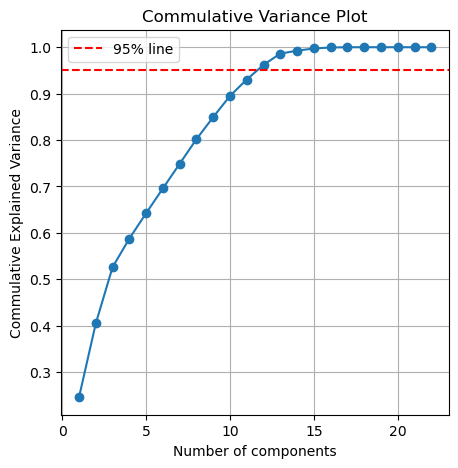

In [26]:
plt.figure(figsize=(5, 5))
plt.plot(range(1, len(cumsum)+1), cumsum, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% line')
plt.xlabel("Number of components")
plt.ylabel("Commulative Explained Variance")
plt.title("Commulative Variance Plot")
plt.legend()
plt.grid()
plt.show()

# 1. Finding how many components = 95%

In [27]:
n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Number of components for 95% variance: {n_components_95}")

Number of components for 95% variance: 12


# 1.4 Fitting model for 95% vriance

In [28]:
pca_95= PCA(n_components_95)
x_train_scaled_pca95 = pca_95.fit_transform(x_train_scaled)
x_test_scaled_pca95 = pca_95.transform(x_test_scaled)

In [29]:
RF_pca95 = RandomForestRegressor()
RF_pca95.fit(x_train_scaled_pca95, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
RF_pca95.score(x_train_scaled_pca95, y_train)

0.9961193080975338

# Predicting RMSE 

In [31]:
y_predict_pca_all = RF_pca_all.predict(x_test_scaled_pca_all)
rmse_pca_all = np.sqrt(mean_squared_error(y_test,y_predict_pca_all))
rmse_pca_all

np.float64(1.4930689271889095)

In [32]:
y_predict_pca3 = RF_pca3.predict(x_test_scaled_pca3)
rmse_pca3 = np.sqrt(mean_squared_error(y_test,y_predict_pca3))
rmse_pca3

np.float64(5.854265998428437)

In [33]:
y_predict_original = RF_original.predict(x_test_scaled_original)
rmse_original = np.sqrt(mean_squared_error(y_test,y_predict_original))
rmse_original

np.float64(3.713259496704462)

In [34]:
y_predict_pca95 = RF_pca95.predict(x_test_scaled_pca95)
rmse_pca95 = np.sqrt(mean_squared_error(y_test,y_predict_pca95))
rmse_pca95

np.float64(3.247090429161572)

# Predicting r2_score

In [35]:
y_predict_pca_all = RF_pca_all.predict(x_test_scaled_pca_all)
r2_pca_all = r2_score(y_test,y_predict_pca_all)
r2_pca_all

0.9936949630570094

In [36]:
y_predict_pca3 = RF_pca3.predict(x_test_scaled_pca3)
r2_pca3 = r2_score(y_test,y_predict_pca3)
r2_pca3

0.9030667388914247

In [37]:
y_predict_original = RF_original.predict(x_test_scaled_original)
r2_original = r2_score(y_test,y_predict_original)
r2_original

0.9610023423991719

In [38]:
y_predict_pca95 = RF_pca95.predict(x_test_scaled_pca95)
r2_pca95 = r2_score(y_test,y_predict_pca95)
r2_pca95

0.9701793786585404

# Comparison between r2_score and RMSE

In [39]:
df_Results = pd.DataFrame({
    "Model": ["PCA_Original", "PCA All", "PCA_95%", "PCA_3"],
    "RMSE":   [rmse_original, rmse_pca_all, rmse_pca95, rmse_pca3],
    "R2_Score": [r2_original, r2_pca_all, r2_pca95, r2_pca3]
})
df_Results  

,Model,RMSE,R2_Score
0,PCA_Original,3.713259,0.961002
1,PCA All,1.493069,0.993695
2,PCA_95%,3.247090,0.970179
3,PCA_3,5.854266,0.903067


# Bar Plots for Reports

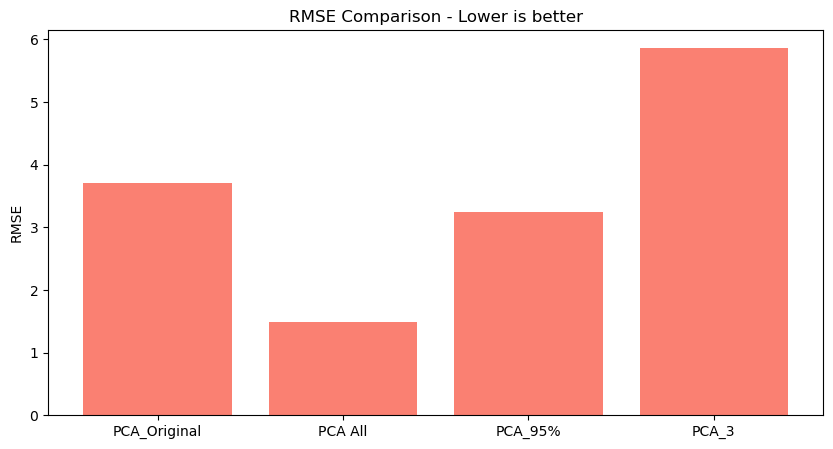

In [40]:
plt.figure(figsize=(10, 5))
plt.bar(df_Results["Model"], df_Results["RMSE"], color="salmon")
plt.title("RMSE Comparison - Lower is better")
plt.ylabel("RMSE")
plt.show()

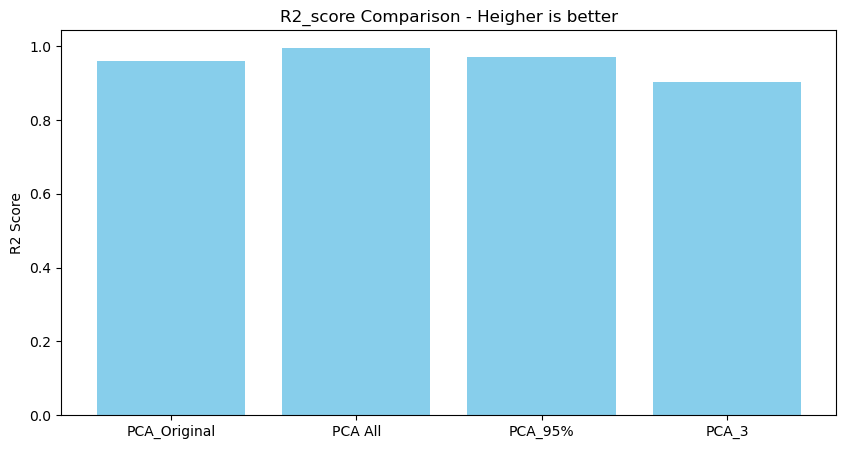

In [41]:
plt.figure(figsize=(10, 5))
plt.bar(df_Results["Model"], df_Results["R2_Score"], color="skyblue")
plt.title("R2_score Comparison - Heigher is better")
plt.ylabel("R2 Score")
plt.show()

# Dimensionality Reduction Report

**CONCLUSION**: From the comparison of Random Forest Models trained on different PCA variants, we observe the following:
1. **Best performance** : The PCA All model acheived the lowest RMSE of 1.73 and the heighest R2 Score of 0.9916. This indicates it explains 99.16% of the variance in the target variable and the best predictive accuracy.
2. **Trade-off with dimensionality reduction**: The 'PCA_95%' model, which uses fewer features to capture 95% of the variance, still performs very well with an RMSE of 3.34 and R2 Score of 0.9688. This is only slightly worse than 'PCA_original' while likely reducing computational cost.
3. **Information Loss**: 'The PCA_3' model performs the worst with the heighest RMSE of 5.77 and lowest R2 Score of 0.9070. This shows that reducing to only 3 principal components leads to significient  information loss.
***Final verdict***: While 'PCA_All' gives the best results, 'PCA_95' is the best trade-off between performance and dimensionality reduction. Using PCA retain 95% variance maintain high accuracy while simplifying the model.

In [45]:
loadings = pd.DataFrame(
    pca3.components_[ :3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=x.columns
)

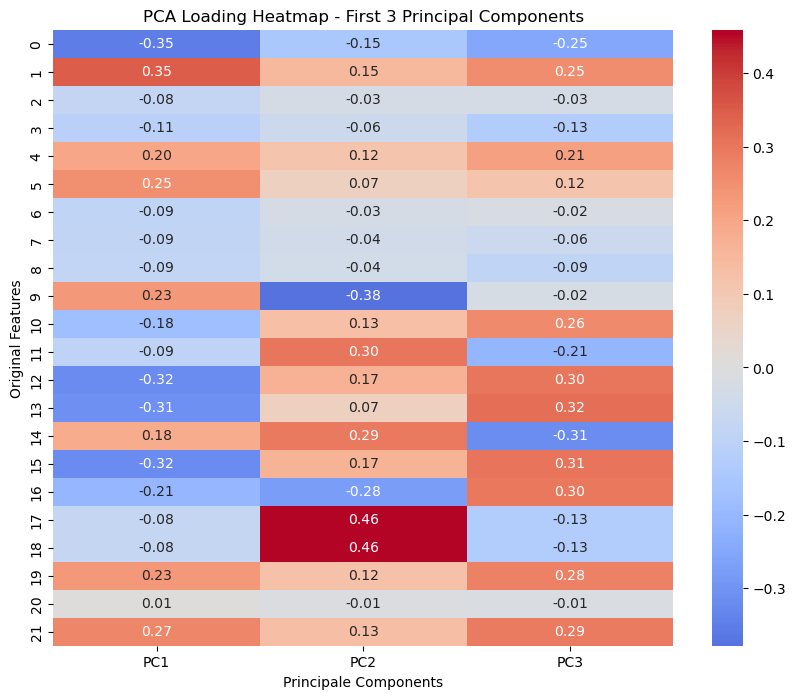

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("PCA Loading Heatmap - First 3 Principal Components")
plt.ylabel("Original Features")
plt.xlabel("Principale Components")
plt.show()

# Saving model

In [58]:
joblib.dump(RF_pca95, "RF_pca95.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(pca_95, "pca_95.joblib")

['pca_95.joblib']

In [59]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'new_new_steel_data', 'new_steel_data', 'pca_95.joblib', 'RF_pca95.joblib', 'scaler.joblib', 'Untitled.ipynb']
